In [ ]:
# Ridge Regression
# Ridge регрессия нужна, когда модель переобучается — слишком точно подстраивается 
# под тренировочные данные вместе с шумом. Она штрафует за слишком большие веса, 
# из-за чего модель становится проще и сглаженнее, хуже "запоминает" тренировочные данные, 
# зато лучше работает на новых.

# Ridge Regression — конспект


Overfitting (веса слишком подстроились, скачут) → Ridge помогает. Увеличиваешь alpha → веса сжимаются → кривая выпрямляется → красная линия перестаёт гнаться за каждой точкой.
Underfitting (модель не дотягивает, слишком плоская/простая) → Ridge не решение, а наоборот, если тут ещё добавить alpha — станет только хуже, модель станет ещё более плоской и ещё сильнее "недотянет". В этом случае нужно:
либо уменьшить alpha (если он и так уже стоит, и это причина недообучения)
либо дать модели больше "инструментов" — например, добавить PolynomialFeatures с нужной степенью, если данные нелинейные (как в твоём примере с параболой)

![ridge](./ridge.png)

## Зачем это вообще нужно

Регуляризация = способ бороться с **overfitting** (переобучением). Чем меньше у модели "свободы" крутить свои параметры как угодно, тем сложнее ей подстроиться под шум в данных вместо реальной закономерности.

Для полиномиальной модели можно просто уменьшить степень полинома. Для линейной модели регуляризацию делают иначе — **ограничивают веса модели**, не давая им расти слишком сильно.

Ridge regression (она же **Tikhonov regularization**) — один из способов такого ограничения.

---

## Формула стоимости (cost function)

```
J(θ) = MSE(θ) + (α/m) * Σ θᵢ²      (сумма от i=1 до n)
```

В псевдокоде:

```js
function costFunction(weights, alpha, m) {
  const mse = calculateMSE(weights); // обычная ошибка модели
  const penalty = (alpha / m) * weights.reduce((sum, w) => sum + w * w, 0);
  return mse + penalty;
}
```

| Символ | Что это |
|---|---|
| `MSE(θ)` | обычная ошибка предсказания |
| `Σ θᵢ²` | сумма квадратов весов — показатель, насколько веса вообще большие |
| `α` (альфа) | ручка регуляризации, крутишь сам (0, 1, 10, 100...) |
| `m` | кол-во примеров в датасете, просто нормировка |
| `θ₀` | bias/intercept — **не** штрафуется (сумма начинается с i=1, не с 0), потому что он просто двигает линию вверх-вниз, а не отвечает за "резкость" кривой |

**Суть:** модель теперь минимизирует не только ошибку, а "ошибку + штраф за большие веса". Приходится искать баланс.

### Что значит α на графике

- **α = 0** → обычная линейная/полиномиальная регрессия, без ограничений → модель может переобучиться (дёргается по каждой точке)
- **α среднее** → баланс между точностью и гладкостью
- **α очень большое** → все веса задавлены почти до нуля → получается плоская линия на уровне среднего `y`

Это компромисс: регуляризация **увеличивает bias** (систематическую ошибку/упрощение), но **уменьшает variance** (чувствительность к шуму) — модель хуже точно повторяет тренировочные данные, зато лучше обобщается на новых.

> ⚠️ Перед Ridge данные обязательно нужно масштабировать (`StandardScaler`). Штраф зависит от размера весов, а размер весов зависит от масштаба признаков — если один признак в тысячах, а другой в долях, их веса несравнимы просто из-за единиц измерения, а не из-за важности.

---

## Разбор графика (Figure 4-18)

**Левый график** — обычная линейная регрессия + Ridge:
- `α=0` (синий пунктир) — обычная прямая, без штрафа
- `α=10` (зелёный) — чуть более "сдержанный" наклон
- `α=100` (красный) — почти плоская линия, близко к среднему `y`

**Правый график** — те же данные, но сначала раздутые в полином 10-й степени (`PolynomialFeatures(degree=10)`), отмасштабированные, и уже потом применён Ridge:
- `α=0` (синий) — дикие скачки вверх-вниз, классический overfitting на высокой степени полинома
- `α=1e-05` (зелёный) — почти без штрафа, всё ещё сильно изгибается
- `α=1` (красный) — гладкая, разумная кривая

Вывод графика: чем выше α, тем более "спокойные" (менее экстремальные) предсказания.

---

## Формула закрытого решения (closed-form / Normal Equation)

Обычная формула линейной регрессии (без регуляризации):
```
θ = (XᵀX)⁻¹ Xᵀy
```

Ridge-версия — **то же самое + один добавленный штрафующий член**:
```
θ = (XᵀX + αA)⁻¹ Xᵀy
```

Разница — только `+ αA` перед инвертированием. Остальное не меняется.

### Что за буквы

- **X** — матрица признаков (таблица: строки — примеры, столбцы — фичи)
- **y** — вектор ответов
- **Xᵀ** (транспонирование) — просто "переворот" матрицы, строки становятся столбцами:

```js
function transpose(matrix) {
  return matrix[0].map((_, col) => matrix.map(row => row[col]));
}
```

- **⁻¹** (обратная матрица) — аналог деления, только для матриц (как `1/x` для чисел)
- **A** — identity-матрица (единичная), но с **0 в левом верхнем углу** (соответствует нерегуляризуемому θ₀):

```
A = [
  [0, 0, 0],
  [0, 1, 0],
  [0, 0, 1]
]
```

- **α** — то же число-ручка, что и в cost function

### Псевдокод целиком

```js
function ridgeClosedForm(X, y, alpha) {
  const Xt = transpose(X);
  const XtX = matMul(Xt, X);
  const A = identityMatrixWithZeroCorner(X[0].length);
  const regularized = matAdd(XtX, matScale(A, alpha)); // XᵀX + αA
  const inverted = matInverse(regularized);
  const XtY = matMul(Xt, y);
  return matMul(inverted, XtY);
}
```

Если `α = 0` → `αA` — матрица нулей → формула превращается обратно в обычный Normal Equation.
Если `α` растёт → добавка "разбавляет" `XᵀX`, из-за чего получаются меньшие, более сглаженные веса.

---

## На практике (sklearn)

```python
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])
```

Или через градиентный спуск (SGD):

```python
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                        max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
```

- `penalty="l2"` — говорит SGD добавлять именно ridge-штраф (квадрат весов)
- обрати внимание: тут `alpha` передают как `0.1 / m` — потому что в SGD нет автоматического деления на `m`, как в формуле выше, поэтому его прописывают руками, чтобы результат совпадал с `Ridge(alpha=0.1)`

**Совет:** `RidgeCV` — то же самое, но с автоматическим подбором `alpha` через кросс-валидацию (аналог `GridSearchCV`, но заточен под ridge и работает быстрее).

---

## TL;DR

Ridge = обычная линейная регрессия + штраф за большие веса (`α * Σθᵢ²`). Чем больше `α`, тем сильнее модель "боится" больших весов → тем более гладкий/плоский получается результат. Это как линтер со строгими правилами: код становится менее "заточенным" под конкретный кейс, зато надёжнее работает в целом.

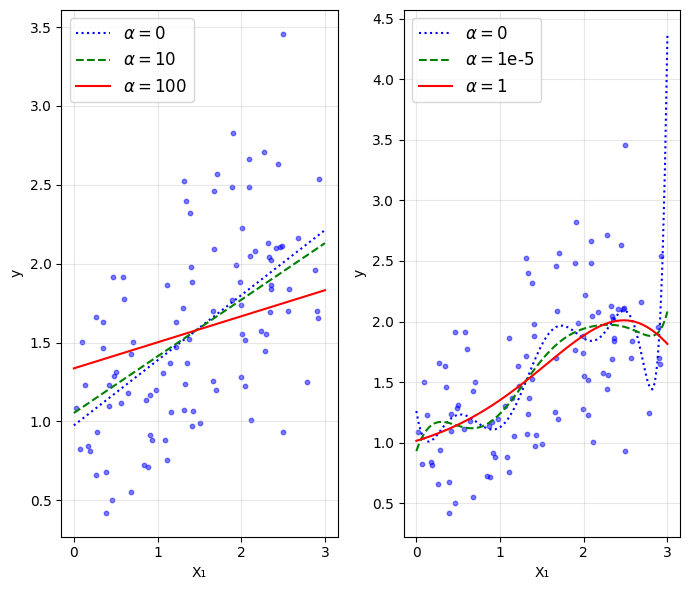

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# Не линейное, квадратичное, ранее с которым мы работали по книге в разделе с полиномами
# y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1)) 
# есть только X (первая степень) → линейно → прямая линия впишется хорошо
# есть X**2, X**3 и т.д. → нелинейно → прямая линия впишется плохо, 
# нужен PolynomialFeatures или другая нелинейная модель


# Генерация данных (линейные с шумом)
rng = np.random.default_rng(42)
m = 100
X = 3 * rng.random((m, 1))  # X в диапазоне [0, 3]
y = 1 + 0.4 * X + rng.standard_normal((m, 1)) * 0.5

# Массив для предсказания (плавная линия)
X_new = np.linspace(0, 3, 100).reshape(-1, 1)

# Размечение сетки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 6))

# === Левый график: линейные ridge-модели ===
ax1.scatter(X, y, c='b', s=10, alpha=0.5)

alphas_linear = [0, 10, 100]
styles = [
    {'color': 'blue', 'linestyle': ':', 'label': r'$\alpha = 0$'},
    {'color': 'green', 'linestyle': '--', 'label': r'$\alpha = 10$'},
    {'color': 'red', 'linestyle': '-', 'label': r'$\alpha = 100$'},
]

for alpha, style in zip(alphas_linear, styles):
    ridge = Ridge(alpha=alpha, solver='cholesky')
    ridge.fit(X, y)
    y_pred = ridge.predict(X_new)
    ax1.plot(X_new, y_pred, **style)

ax1.set_xlabel('X₁')
ax1.set_ylabel('y')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# === Правый график: полиномиальные ridge-модели ===
# Тут расширенный с PolynomialFeatures и скейлим с StandardScaler
# this is polynomial regression with ridge regularization
ax2.scatter(X, y, c='b', s=10, alpha=0.5)

alphas_poly = [0, 1e-5, 1]
styles_poly = [
    {'color': 'blue', 'linestyle': ':', 'label': r'$\alpha = 0$'},
    {'color': 'green', 'linestyle': '--', 'label': r'$\alpha = 1\text{e-}5$'},
    {'color': 'red', 'linestyle': '-', 'label': r'$\alpha = 1$'},
]

for alpha, style in zip(alphas_poly, styles_poly):
    pipe = make_pipeline(
        PolynomialFeatures(degree=10),
        StandardScaler(),
        Ridge(alpha=alpha, solver='cholesky')
    )
    pipe.fit(X, y)
    y_pred = pipe.predict(X_new)
    ax2.plot(X_new, y_pred, **style)

ax2.set_xlabel('X₁')
ax2.set_ylabel('y')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Closed-form (готовая формула), одним махом (XᵀX+αA)⁻¹Xᵀy
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.59348264]])

In [ ]:
# Gradient Descent (постепенный подбор) — SGDRegressor.
#  Тут веса не вычисляются формулой сразу, а подбираются итеративно
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
 max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])


array([1.59249832])

In [ ]:
# Зачем нужны оба, если есть готовая формула

# closed-form есть слабое место — эта формула требует обращения матрицы (⁻¹), 
# а это дорогая операция, которая на больших датасетах (много строк и/или очень много признаков) 
# становится очень медленной или вообще нереальной по памяти.

# SGDRegressor (gradient descent) масштабируется лучше на больших данных — можно кормить данные 
# "порциями" (stochastic — по одному примеру за раз), не держа всё в памяти разом.

# параметр penalty="l2" говорит ему: "добавь именно ℓ2-регуляризацию" (то есть веди себя как Ridge, 
# а не как обычная линейная регрессия без штрафа).